In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "908803302"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"])
df

,Model,Compression,BLEU
0,pythia-70M,Original,0.41996
1,pythia-70M,8-bit,0.41390
2,pythia-70M,4-bit,0.39210
3,pythia-160M,Original,0.42493
4,pythia-160M,8-bit,0.42310
5,pythia-160M,4-bit,0.40604
6,pythia-410M,Original,0.43509
7,pythia-410M,8-bit,0.43612
8,pythia-410M,4-bit,0.42411
9,pythia-1B,Original,0.44180


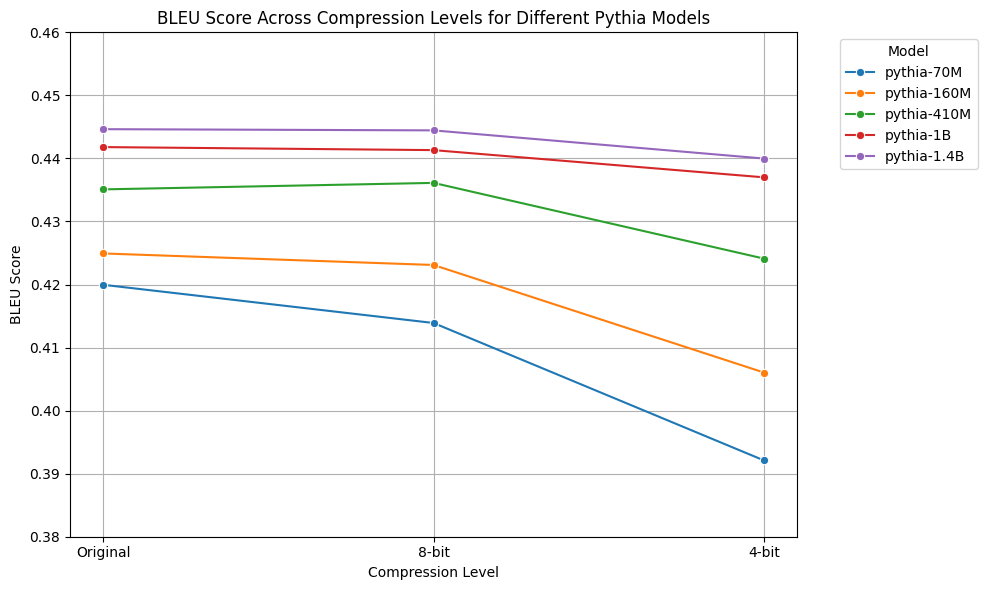

In [2]:
compression_order = ["Original", "8-bit", "4-bit"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o")

plt.title("BLEU Score Across Compression Levels for Different Pythia Models")
plt.ylabel("BLEU Score")
plt.xlabel("Compression Level")
plt.ylim(0.38, 0.46)
plt.grid(True)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("./output/RQ-1.png", dpi=300, bbox_inches="tight")
plt.show()

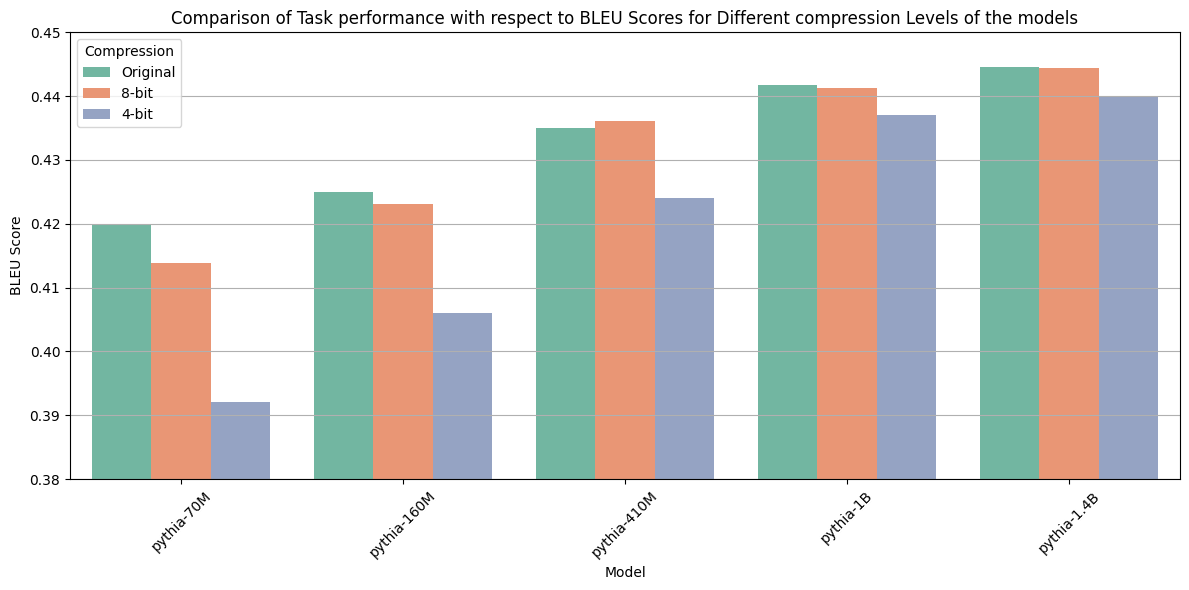

In [3]:

compression_order = ["Original", "8-bit", "4-bit"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Model", y="BLEU", hue="Compression", palette="Set2")

# Add labels and title
plt.title("Comparison of Task performance with respect to BLEU Scores for Different compression Levels of the models")
plt.xlabel("Model")
plt.ylabel("BLEU Score")
plt.ylim(0.38, 0.45)
plt.xticks(rotation=45)
plt.legend(title="Compression")
plt.tight_layout()
plt.grid(axis='y')
plt.savefig("./output/RQ1.png", dpi=300, bbox_inches="tight")
# Show plot
plt.show()